# Predictive Maintenance — Exploratory Data Analysis

This notebook performs exploratory data analysis on the cleaned AI4I 2020 Predictive Maintenance Dataset.

## Objectives

- Understand the distribution of machine operating conditions
- Analyze the distribution of machine failures
- Compare normal and failed machine observations
- Investigate relationships between sensor variables
- Identify potentially important features for machine failure prediction
- Generate initial findings to guide feature engineering and model development

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data = pd.read_csv("../data/processed/cleaned_data.csv")
data.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure
0,M,298.1,308.6,1551,42.8,0,0
1,L,298.2,308.7,1408,46.3,3,0
2,L,298.1,308.5,1498,49.4,5,0
3,L,298.2,308.6,1433,39.5,7,0
4,L,298.2,308.7,1408,40.0,9,0


In [4]:
print("Dataset shape:", data.shape)

Dataset shape: (10000, 7)


In [5]:
print(data.dtypes)

Type                           str
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
Machine failure              int64
dtype: object


In [6]:
print(data.isnull().sum().sum())

0


In [7]:
data.describe()

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900
std,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981
min,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000
25%,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000
50%,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000
75%,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000
max,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000


In [8]:
numerical_features = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]

In [9]:
failure_counts = data["Machine failure"].value_counts()

print(failure_counts)

Machine failure
0    9661
1     339
Name: count, dtype: int64


In [10]:
failure_percentages = data["Machine failure"].value_counts(normalize=True) * 100

print(failure_percentages)

Machine failure
0    96.61
1     3.39
Name: proportion, dtype: float64


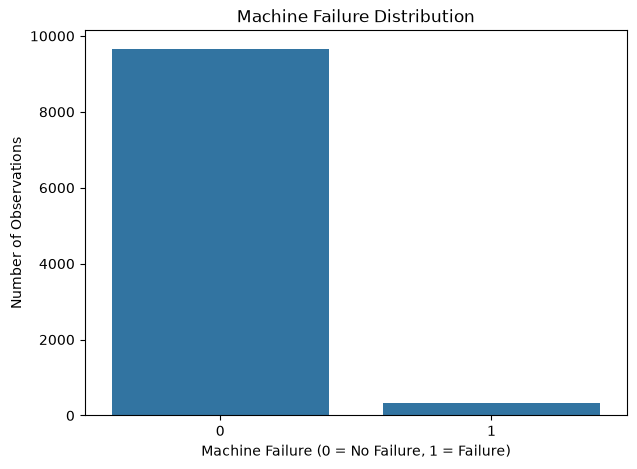

In [11]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=data,
    x="Machine failure"
)

plt.title("Machine Failure Distribution")
plt.xlabel("Machine Failure (0 = No Failure, 1 = Failure)")
plt.ylabel("Number of Observations")

plt.show()

### Finding: Class Distribution

The dataset contains 9,661 normal observations and 339 machine-failure observations. Therefore, approximately 96.61% of observations represent normal operation while only 3.39% represent failure. This significant class imbalance means that accuracy alone may not be sufficient for evaluating the machine failure prediction model.

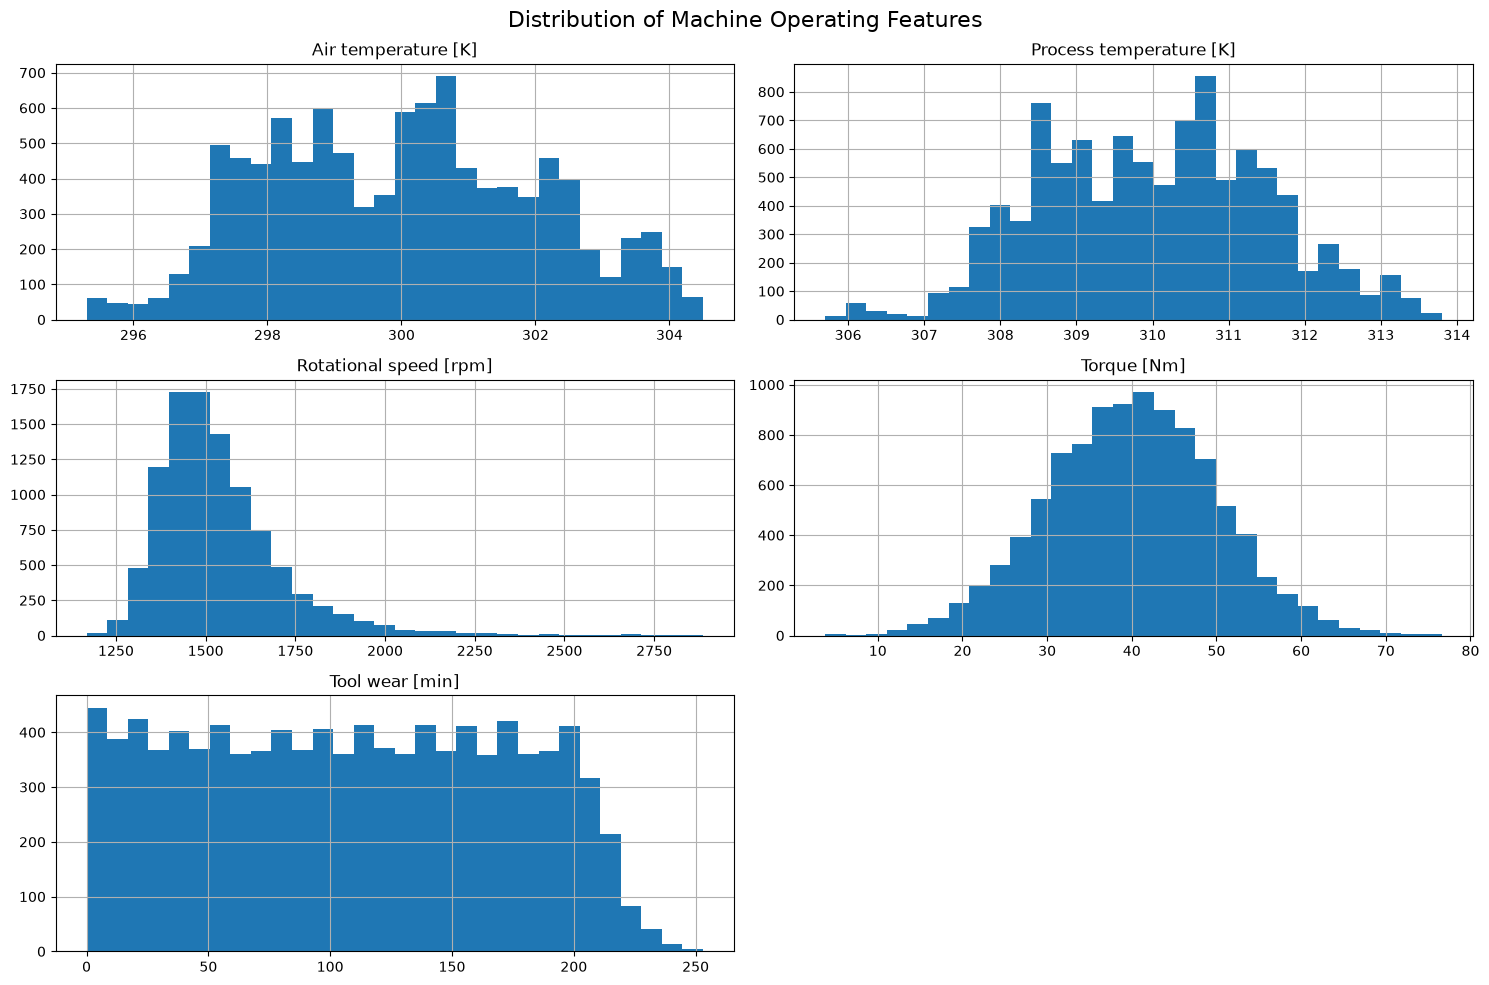

In [12]:
data[numerical_features].hist(
    figsize=(15, 10),
    bins=30
)

plt.suptitle("Distribution of Machine Operating Features", fontsize=16)

plt.tight_layout()
plt.show()

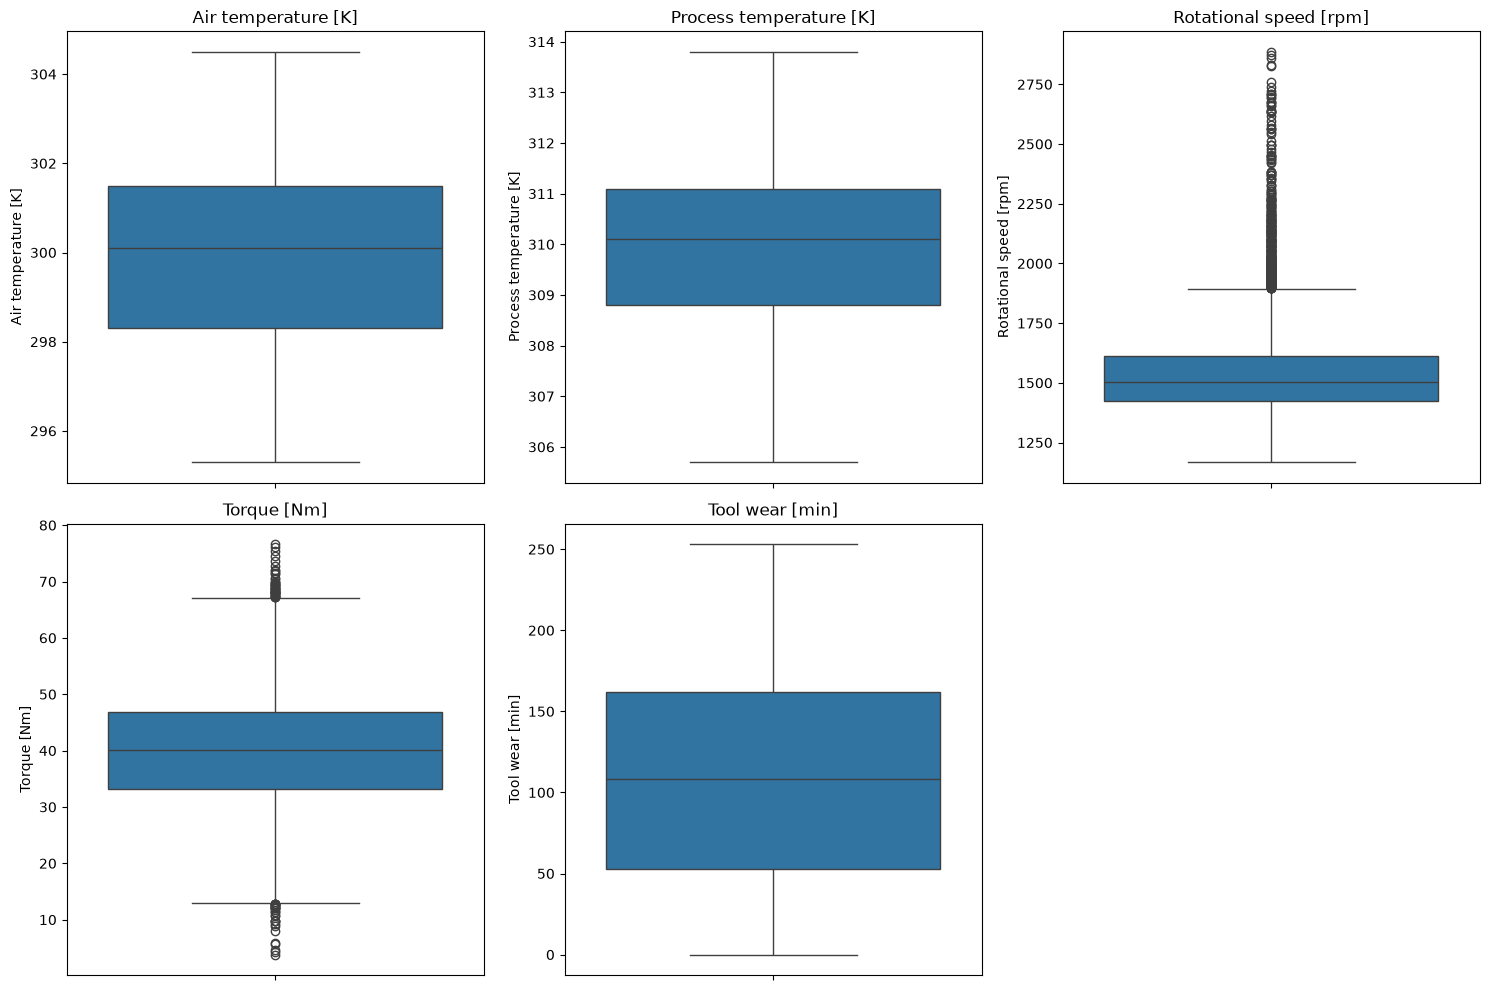

In [13]:
plt.figure(figsize=(15, 10))

for i, feature in enumerate(numerical_features, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(data=data, y=feature)
    plt.title(feature)

plt.tight_layout()
plt.show()

In [14]:
failure_means = data.groupby("Machine failure")[numerical_features].mean()

failure_means

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min]
Machine failure,,,,,
0,299.973999,309.995570,1540.260014,39.629655,106.693717
1,300.886431,310.290265,1496.486726,50.168142,143.781711


In [15]:
normal_means = data[data["Machine failure"] == 0][numerical_features].mean()

failure_means_only = data[data["Machine failure"] == 1][numerical_features].mean()

comparison = pd.DataFrame({
    "Normal Mean": normal_means,
    "Failure Mean": failure_means_only
})

comparison["Difference"] = (
    comparison["Failure Mean"] - comparison["Normal Mean"]
)

comparison

,Normal Mean,Failure Mean,Difference
Air temperature [K],299.973999,300.886431,0.912432
Process temperature [K],309.995570,310.290265,0.294696
Rotational speed [rpm],1540.260014,1496.486726,-43.773289
Torque [Nm],39.629655,50.168142,10.538486
Tool wear [min],106.693717,143.781711,37.087994


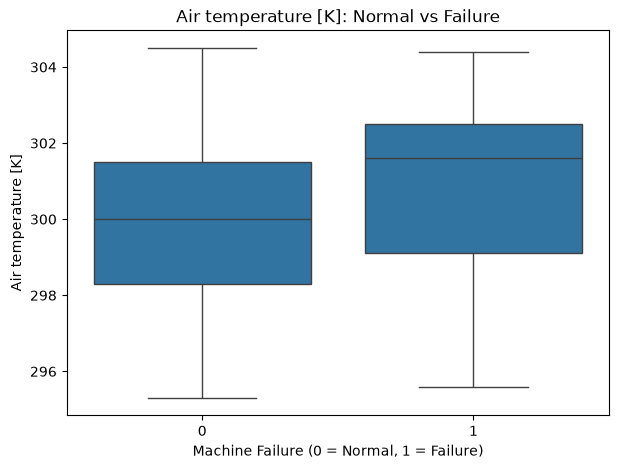

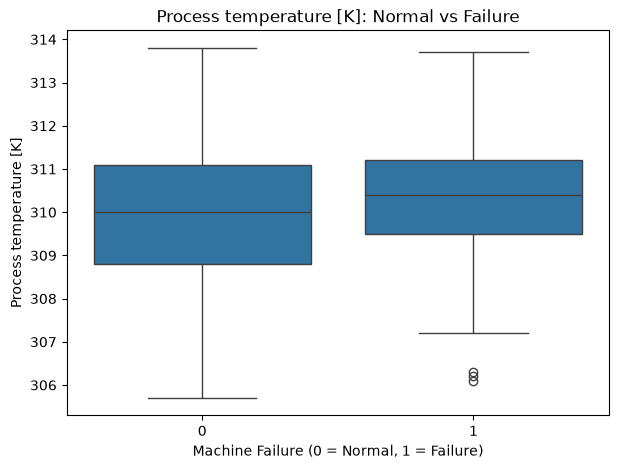

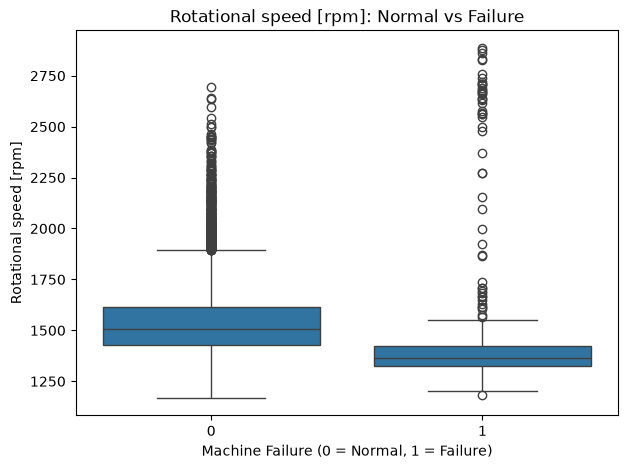

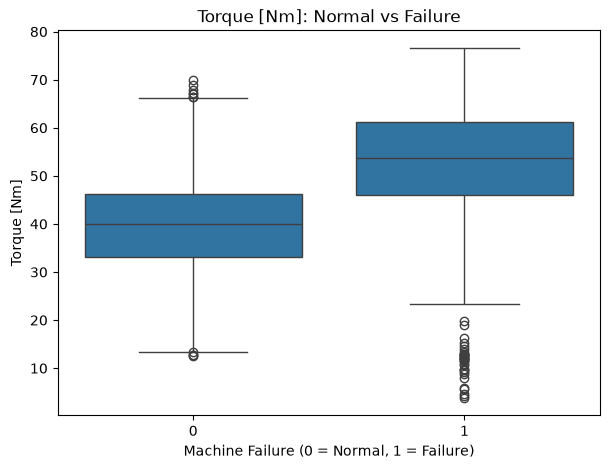

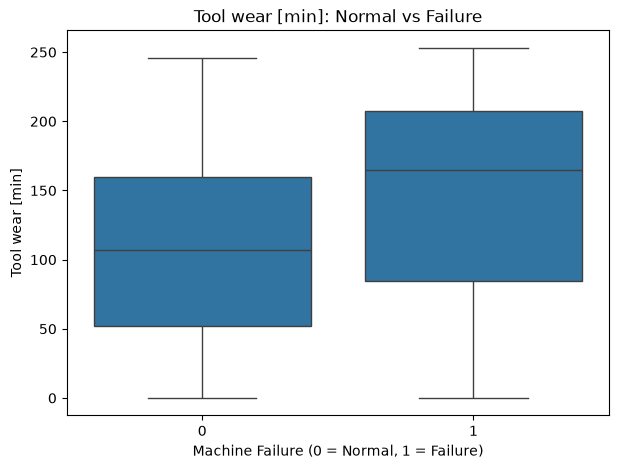

In [16]:
for feature in numerical_features:

    plt.figure(figsize=(7, 5))

    sns.boxplot(
        data=data,
        x="Machine failure",
        y=feature
    )

    plt.title(f"{feature}: Normal vs Failure")
    plt.xlabel("Machine Failure (0 = Normal, 1 = Failure)")
    plt.ylabel(feature)

    plt.show()

In [17]:
type_failure_rate = (
    data.groupby("Type")["Machine failure"]
    .mean()
    .sort_values(ascending=False)
)

print(type_failure_rate)

Type
L    0.039167
M    0.027694
H    0.020937
Name: Machine failure, dtype: float64


In [18]:
type_failure_rate_percentage = type_failure_rate * 100

print(type_failure_rate_percentage)

Type
L    3.916667
M    2.769436
H    2.093719
Name: Machine failure, dtype: float64


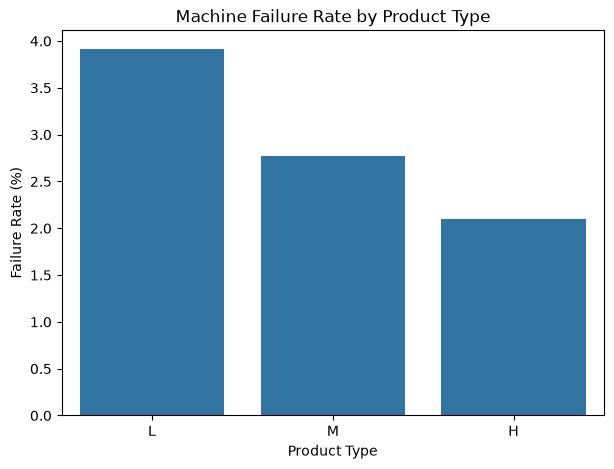

In [19]:
plt.figure(figsize=(7, 5))

sns.barplot(
    x=type_failure_rate_percentage.index,
    y=type_failure_rate_percentage.values
)

plt.title("Machine Failure Rate by Product Type")
plt.xlabel("Product Type")
plt.ylabel("Failure Rate (%)")

plt.show()

In [20]:
correlation_matrix = data[numerical_features + ["Machine failure"]].corr()

correlation_matrix

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure
Air temperature [K],1.000000,0.876107,0.022670,-0.013778,0.013853,0.082556
Process temperature [K],0.876107,1.000000,0.019277,-0.014061,0.013488,0.035946
Rotational speed [rpm],0.022670,0.019277,1.000000,-0.875027,0.000223,-0.044188
Torque [Nm],-0.013778,-0.014061,-0.875027,1.000000,-0.003093,0.191321
Tool wear [min],0.013853,0.013488,0.000223,-0.003093,1.000000,0.105448
Machine failure,0.082556,0.035946,-0.044188,0.191321,0.105448,1.000000


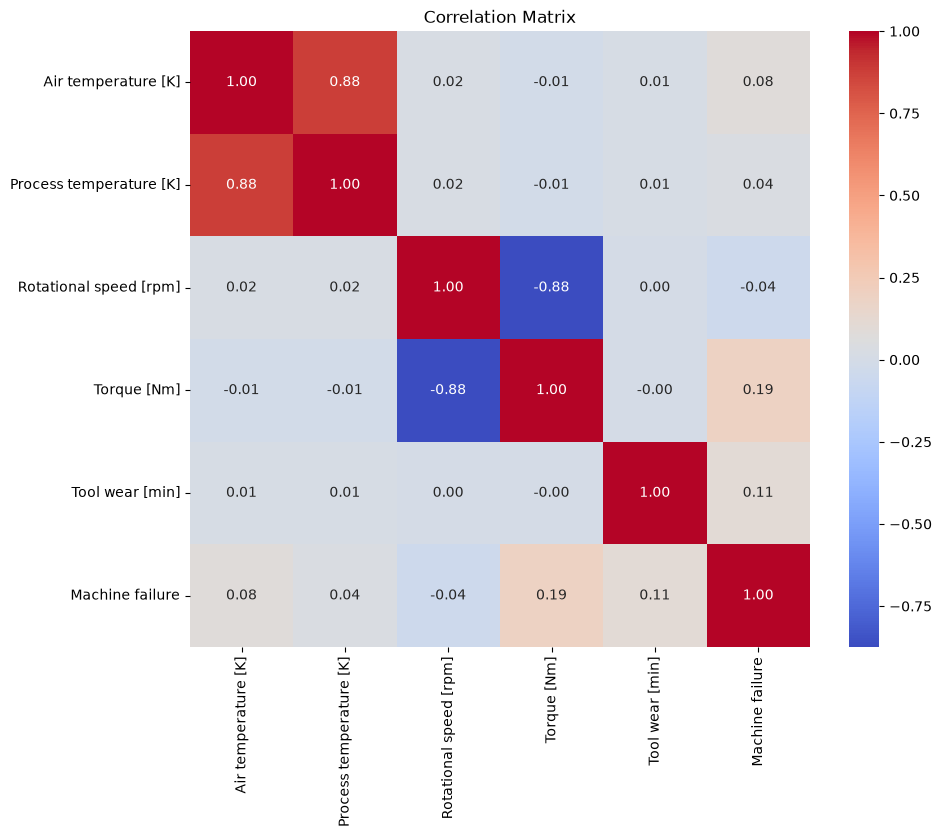

In [21]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

In [22]:
failure_correlations = (
    correlation_matrix["Machine failure"]
    .drop("Machine failure")
    .sort_values(key=abs, ascending=False)
)

print(failure_correlations)

Torque [Nm]                0.191321
Tool wear [min]            0.105448
Air temperature [K]        0.082556
Rotational speed [rpm]    -0.044188
Process temperature [K]    0.035946
Name: Machine failure, dtype: float64


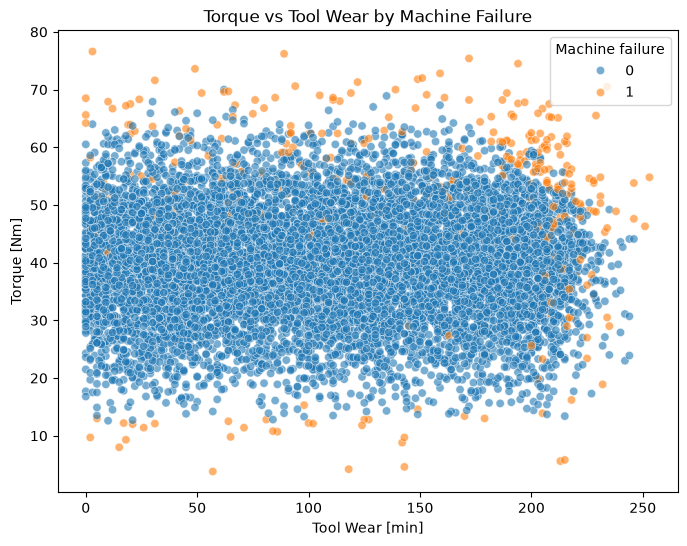

In [23]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=data,
    x="Tool wear [min]",
    y="Torque [Nm]",
    hue="Machine failure",
    alpha=0.6
)

plt.title("Torque vs Tool Wear by Machine Failure")
plt.xlabel("Tool Wear [min]")
plt.ylabel("Torque [Nm]")

plt.show()

In [24]:
data["Temperature difference [K]"] = (
    data["Process temperature [K]"]
    - data["Air temperature [K]"]
)

In [25]:
data["Temperature difference [K]"].describe()

count    10000.000000
mean        10.000630
std          1.001094
min          7.600000
25%          9.300000
50%          9.800000
75%         11.000000
max         12.100000
Name: Temperature difference [K], dtype: float64

In [26]:
data.groupby("Machine failure")[
    "Temperature difference [K]"
].mean()

Machine failure
0    10.021571
1     9.403835
Name: Temperature difference [K], dtype: float64

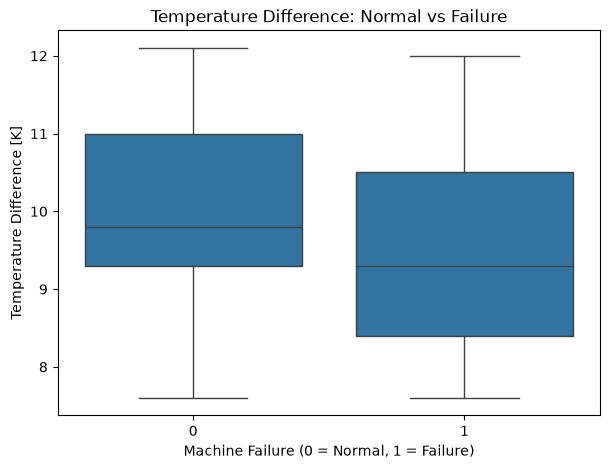

In [27]:
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=data,
    x="Machine failure",
    y="Temperature difference [K]"
)

plt.title("Temperature Difference: Normal vs Failure")
plt.xlabel("Machine Failure (0 = Normal, 1 = Failure)")
plt.ylabel("Temperature Difference [K]")

plt.show()

In [28]:
data["Tool wear group"] = pd.cut(
    data["Tool wear [min]"],
    bins=[-1, 50, 100, 150, 200, 250, 300],
    labels=[
        "0-50",
        "51-100",
        "101-150",
        "151-200",
        "201-250",
        "251-300"
    ]
)

In [29]:
tool_wear_failure_rate = (
    data.groupby("Tool wear group", observed=True)["Machine failure"]
    .mean() * 100
)

print(tool_wear_failure_rate)

Tool wear group
0-50         2.170284
51-100       2.333774
101-150      2.178649
151-200      2.899824
201-250     15.263158
251-300    100.000000
Name: Machine failure, dtype: float64


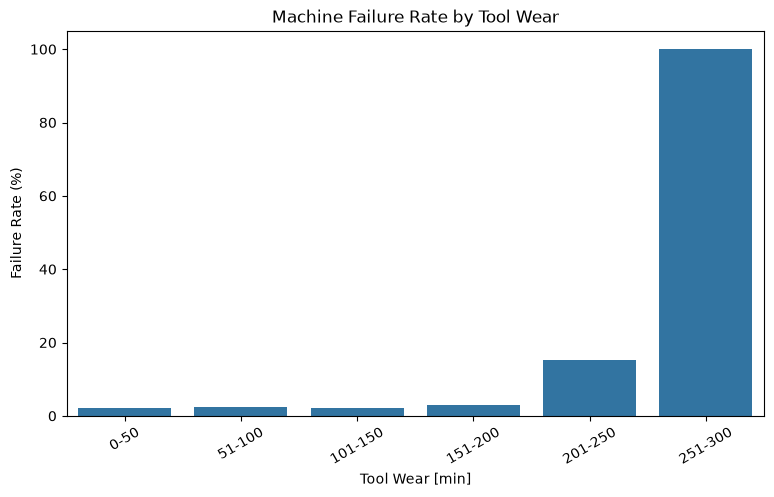

In [30]:
plt.figure(figsize=(9, 5))

sns.barplot(
    x=tool_wear_failure_rate.index,
    y=tool_wear_failure_rate.values
)

plt.title("Machine Failure Rate by Tool Wear")
plt.xlabel("Tool Wear [min]")
plt.ylabel("Failure Rate (%)")

plt.xticks(rotation=30)

plt.show()

In [31]:
data["Torque group"] = pd.cut(
    data["Torque [Nm]"],
    bins=5
)

In [32]:
torque_failure_rate = (
    data.groupby("Torque group", observed=True)["Machine failure"]
    .mean() * 100
)

print(torque_failure_rate)

Torque group
(3.727, 18.36]    21.333333
(18.36, 32.92]     0.657895
(32.92, 47.48]     0.963355
(47.48, 62.04]     7.738928
(62.04, 76.6]     57.251908
Name: Machine failure, dtype: float64


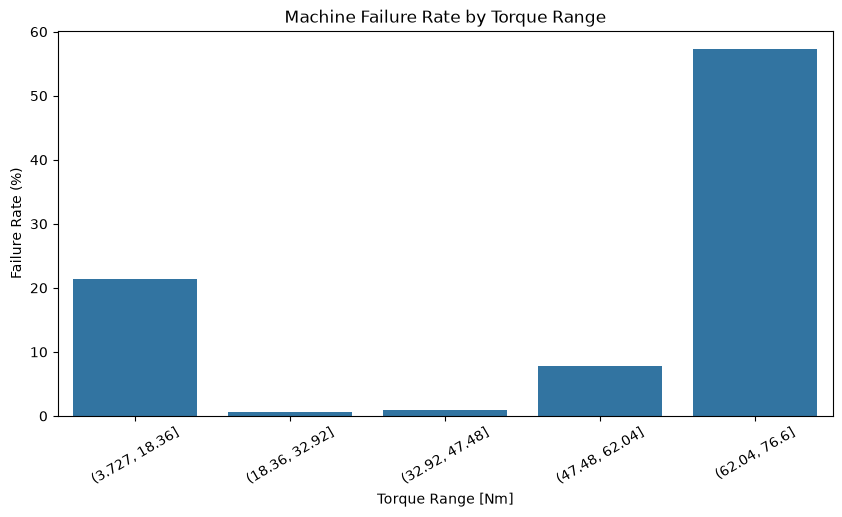

In [33]:
plt.figure(figsize=(10, 5))

sns.barplot(
    x=torque_failure_rate.index.astype(str),
    y=torque_failure_rate.values
)

plt.title("Machine Failure Rate by Torque Range")
plt.xlabel("Torque Range [Nm]")
plt.ylabel("Failure Rate (%)")

plt.xticks(rotation=30)

plt.show()

In [34]:
data["Speed group"] = pd.cut(
    data["Rotational speed [rpm]"],
    bins=5
)

In [35]:
speed_failure_rate = (
    data.groupby("Speed group", observed=True)["Machine failure"]
    .mean() * 100
)

print(speed_failure_rate)

Speed group
(1166.282, 1511.6]     5.350343
(1511.6, 1855.2]       0.498339
(1855.2, 2198.8]       1.369863
(2198.8, 2542.4]       7.575758
(2542.4, 2886.0]      86.666667
Name: Machine failure, dtype: float64


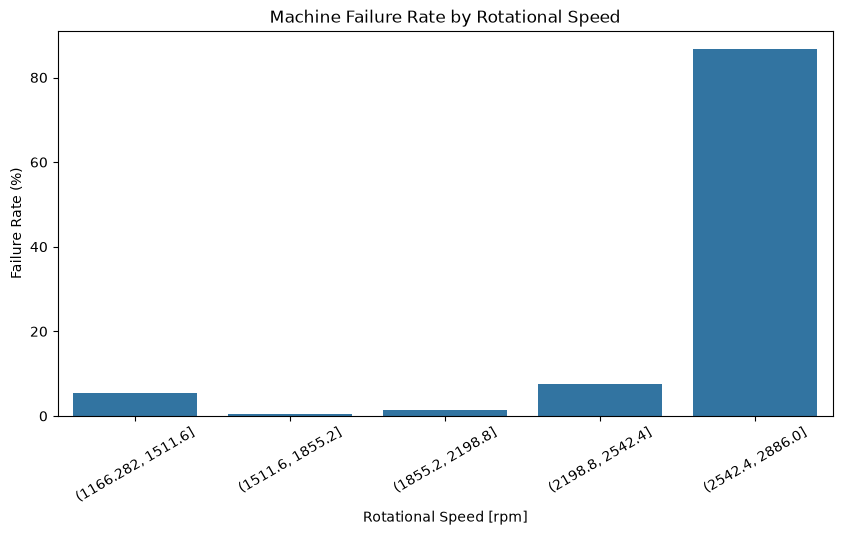

In [36]:
plt.figure(figsize=(10, 5))

sns.barplot(
    x=speed_failure_rate.index.astype(str),
    y=speed_failure_rate.values
)

plt.title("Machine Failure Rate by Rotational Speed")
plt.xlabel("Rotational Speed [rpm]")
plt.ylabel("Failure Rate (%)")

plt.xticks(rotation=30)

plt.show()

In [37]:
eda_only_columns = [
    "Temperature difference [K]",
    "Tool wear group",
    "Torque group",
    "Speed group"
]

data = data.drop(columns=eda_only_columns)

In [38]:
print(data.columns.tolist())

['Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure']


In [39]:
eda_summary = pd.DataFrame({
    "Feature": numerical_features,
    "Normal Mean": [
        data[data["Machine failure"] == 0][feature].mean()
        for feature in numerical_features
    ],
    "Failure Mean": [
        data[data["Machine failure"] == 1][feature].mean()
        for feature in numerical_features
    ]
})

eda_summary["Difference"] = (
    eda_summary["Failure Mean"]
    - eda_summary["Normal Mean"]
)

eda_summary

,Feature,Normal Mean,Failure Mean,Difference
0,Air temperature [K],299.973999,300.886431,0.912432
1,Process temperature [K],309.995570,310.290265,0.294696
2,Rotational speed [rpm],1540.260014,1496.486726,-43.773289
3,Torque [Nm],39.629655,50.168142,10.538486
4,Tool wear [min],106.693717,143.781711,37.087994


## EDA Findings

### 1. Class Imbalance
The dataset contains 9,661 normal observations and 339 failure observations, meaning that only 3.39% of observations correspond to machine failure. This confirms that class imbalance must be considered during model training and evaluation.

### 2. Machine Operating Conditions
The numerical features show different distributions across normal and failure observations. Differences in temperature, rotational speed, torque and tool wear will be investigated further during feature engineering and model development.

### 3. Product Type
Failure rates vary across product types, indicating that `Type` may provide useful predictive information.

### 4. Tool Wear
Failure rates were analyzed across different tool-wear ranges to investigate whether increasing tool wear is associated with increased machine failure risk.

### 5. Torque and Rotational Speed
Failure rates were analyzed across torque and rotational-speed ranges to identify potentially important operating regions.

### 6. Temperature
The relationship between air temperature, process temperature and their difference was investigated to determine whether thermal operating conditions may contribute useful predictive information.

### 7. Correlation
Correlation analysis was performed to identify linear relationships between numerical features and machine failure. However, correlation alone is not sufficient for feature selection because machine failure may depend on nonlinear relationships and interactions between multiple variables.

### 8. Next Step
The EDA findings will be used to guide feature engineering and machine learning model development in the next phases.